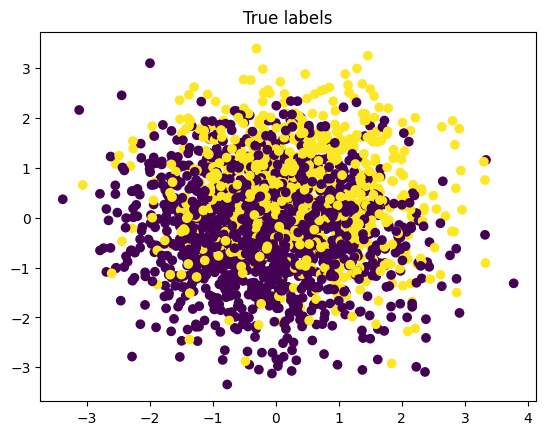

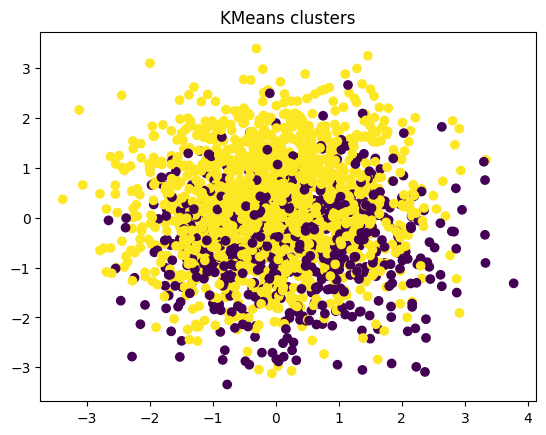

Clustering accuracy: 0.5602605863192183
ARI: -0.002354004121024388
NMI: 6.839576952012152e-05
Silhouette: 0.0471599533477378


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


df = pd.read_csv("data/alzheimers_disease_data.csv")

# Drop non-useful
df = df.drop(columns=["PatientID", "DoctorInCharge"])

# Encode
df = pd.get_dummies(df, drop_first=True)

# Split X / y
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# Scale (IMPORTANT for clustering)
X_scaled = StandardScaler().fit_transform(X)

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# --- Align cluster labels (very important) ---
# clusters are arbitrary (0/1 may be flipped)
acc1 = accuracy_score(y, clusters)
acc2 = accuracy_score(y, 1 - clusters)

accuracy = max(acc1, acc2)

X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("True labels")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("KMeans clusters")
plt.show()

print("Clustering accuracy:", accuracy)
print("ARI:", adjusted_rand_score(y, clusters))
print("NMI:", normalized_mutual_info_score(y, clusters))
print("Silhouette:", silhouette_score(X_scaled, clusters))